# MSR-VTT Dataset Viewer

**模态**: Video + Text (video-caption pairs)

- 10,000 video clips, 200,000 captions
- train_7k / train_9k / test_1k splits
- 20 categories (music, sports, cooking, animals, ...)
- 用于 video-text 检索、video captioning、video QA

In [1]:
import os
import json
import zipfile
import random
import tempfile
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

BASE = os.path.abspath(os.path.join(os.getcwd(), '..', 'dataset', 'MSR-VTT'))
TRAIN_9K = os.path.join(BASE, 'msrvtt_train_9k.json')
TRAIN_7K = os.path.join(BASE, 'msrvtt_train_7k.json')
TEST_1K = os.path.join(BASE, 'msrvtt_test_1k.json')
VIDEOS_ZIP = os.path.join(BASE, 'MSRVTT_Videos.zip')

with open(TRAIN_9K) as f:
    train9k = json.load(f)
with open(TRAIN_7K) as f:
    train7k = json.load(f)
with open(TEST_1K) as f:
    test1k = json.load(f)

print(f'train_9k: {len(train9k)} entries')
print(f'train_7k: {len(train7k)} entries')
print(f'test_1k:  {len(test1k)} entries')
print(f'Videos ZIP: {os.path.exists(VIDEOS_ZIP)} ({os.path.getsize(VIDEOS_ZIP)/1e9:.2f} GB)')

train_9k: 9000 entries
train_7k: 7010 entries
test_1k:  1000 entries
Videos ZIP: True (2.19 GB)


## 1. Data Schema

In [2]:
item = train9k[0]
print('=== Train item schema ===')
for k, v in item.items():
    val_repr = json.dumps(v, ensure_ascii=False)[:120] if not isinstance(v, str) else v[:120]
    print(f'  {k:15s} ({type(v).__name__:6s}): {val_repr}')

print(f'\n=== Test item schema ===')
item_t = test1k[0]
for k, v in item_t.items():
    val_repr = json.dumps(v, ensure_ascii=False)[:120] if not isinstance(v, str) else v[:120]
    print(f'  {k:15s} ({type(v).__name__:6s}): {val_repr}')

=== Train item schema ===
  video_id        (str   ): video0
  video           (str   ): video0.mp4
  caption         (list  ): ["a car is shown", "a group is dancing", "a man drives a vehicle through the countryside", "a man drives down the road i
  source          (str   ): MSR-VTT
  category        (int   ): 9
  url             (str   ): https://www.youtube.com/watch?v=9lZi22qLlEo
  start time      (float ): 137.72
  end time        (float ): 149.44
  id              (int   ): 0

=== Test item schema ===
  video_id        (str   ): video7020
  video           (str   ): video7020.mp4
  caption         (str   ): a woman creating a fondant baby and flower
  source          (str   ): MSR-VTT
  category        (int   ): 10
  url             (str   ): https://www.youtube.com/watch?v=4KRMJNBjrEs
  start time      (float ): 221.77
  end time        (float ): 233.08
  id              (int   ): 7020


## 2. Category Distribution

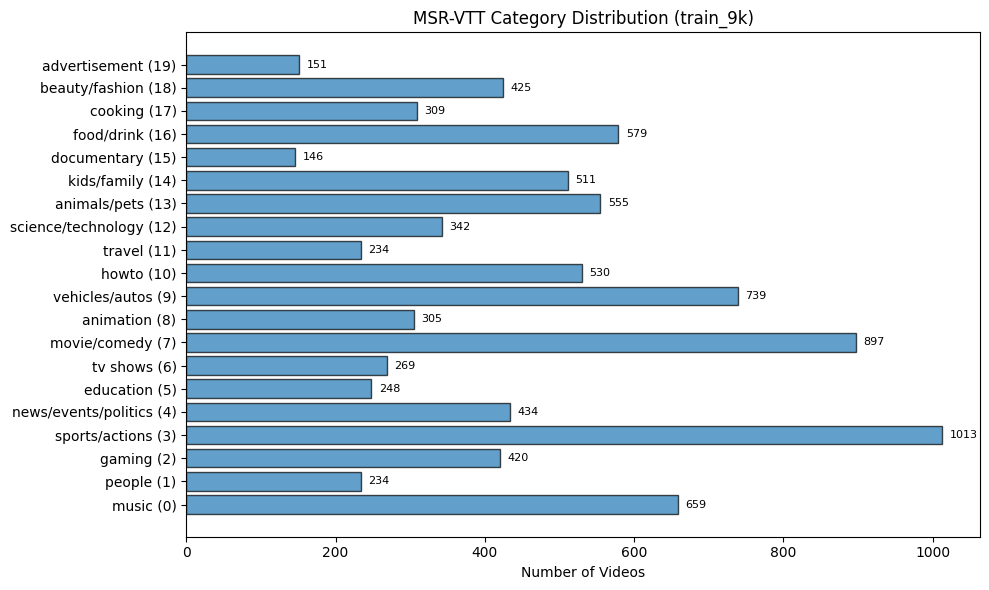

In [3]:
with open(os.path.join(BASE, 'raw_data', 'category.txt')) as f:
    cat_lines = f.read().strip().split('\n')
cat_map = {}
for line in cat_lines:
    name, idx = line.rsplit('\t', 1)
    cat_map[int(idx)] = name

cat_counts = Counter(item['category'] for item in train9k)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
labels = [f'{cat_map[cid]} ({cid})' for cid in sorted(cat_counts)]
values = [cat_counts[cid] for cid in sorted(cat_counts)]
bars = ax.barh(labels, values, edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of Videos')
ax.set_title('MSR-VTT Category Distribution (train_9k)')
for bar, v in zip(bars, values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 3. Caption Statistics

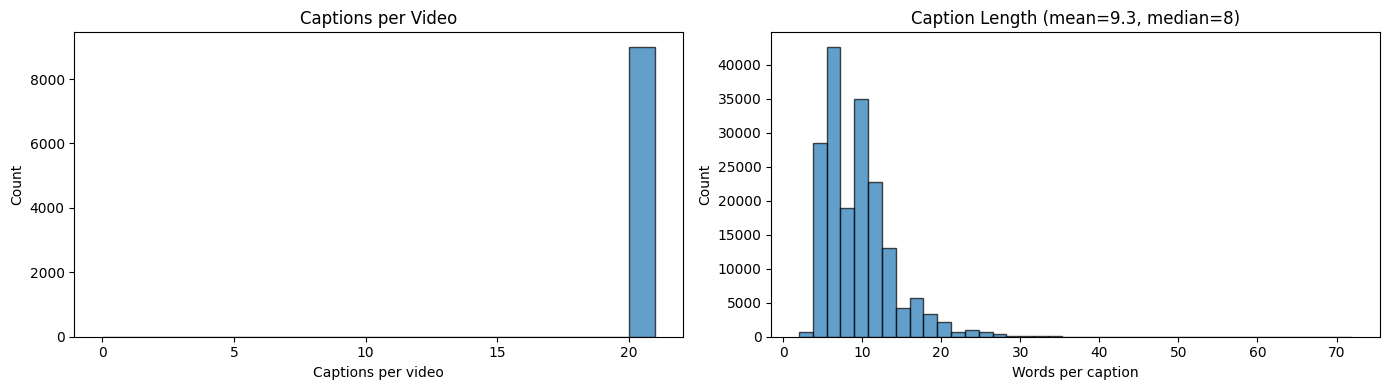

Total captions (train_9k): 180000
Captions/video: min=20, max=20, mean=20.0
Words/caption: min=2, max=72, mean=9.3


In [4]:
all_captions = []
caps_per_video = []
for item in train9k:
    caps = item['caption'] if isinstance(item['caption'], list) else [item['caption']]
    caps_per_video.append(len(caps))
    all_captions.extend(caps)

lengths = [len(c.split()) for c in all_captions]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(caps_per_video, bins=range(0, max(caps_per_video)+2), edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Captions per video')
axes[0].set_ylabel('Count')
axes[0].set_title('Captions per Video')

axes[1].hist(lengths, bins=40, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Words per caption')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Caption Length (mean={np.mean(lengths):.1f}, median={np.median(lengths):.0f})')
plt.tight_layout()
plt.show()

print(f'Total captions (train_9k): {len(all_captions)}')
print(f'Captions/video: min={min(caps_per_video)}, max={max(caps_per_video)}, mean={np.mean(caps_per_video):.1f}')
print(f'Words/caption: min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.1f}')

## 4. Video Duration Distribution

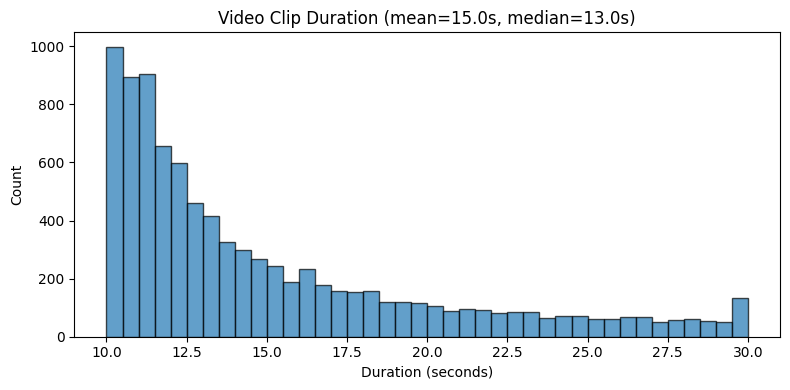

Duration range: 10.0s - 30.0s


In [5]:
durations = []
for item in train9k:
    start = item.get('start time', 0)
    end = item.get('end time', 0)
    durations.append(end - start)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(durations, bins=40, edgecolor='black', alpha=0.7)
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Count')
ax.set_title(f'Video Clip Duration (mean={np.mean(durations):.1f}s, median={np.median(durations):.1f}s)')
plt.tight_layout()
plt.show()
print(f'Duration range: {min(durations):.1f}s - {max(durations):.1f}s')

## 5. Preview Video Frames + Captions (requires opencv-python)

In [6]:
try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False
    print('pip install opencv-python  # required for video frame extraction')

N_SHOW = 6
random.seed(42)
samples = random.sample(train9k, min(N_SHOW, len(train9k)))

if HAS_CV2:
    zip_ref = zipfile.ZipFile(VIDEOS_ZIP, 'r')
    video_names_list = zip_ref.namelist()

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ax, item in zip(axes.flat, samples):
        vid_name = item['video']
        candidates = [n for n in video_names_list if n.endswith(vid_name)]
        frame_rgb = None
        if candidates:
            data = zip_ref.read(candidates[0])
            with tempfile.NamedTemporaryFile(suffix='.mp4', delete=False) as tmp:
                tmp.write(data)
                tmp_path = tmp.name
            cap = cv2.VideoCapture(tmp_path)
            ret, frame = cap.read()
            cap.release()
            os.unlink(tmp_path)
            if ret:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        if frame_rgb is not None:
            ax.imshow(frame_rgb)
        else:
            ax.text(0.5, 0.5, f'{vid_name}\nframe extraction failed',
                    ha='center', va='center', transform=ax.transAxes)
        caps = item['caption'][:2] if isinstance(item['caption'], list) else [item['caption']]
        cat_name = cat_map.get(item.get('category', -1), '?')
        ax.set_title(f'{vid_name} [{cat_name}]\n{"; ".join(caps)}', fontsize=7, loc='left')
        ax.axis('off')
    zip_ref.close()
    plt.tight_layout()
    plt.show()
else:
    print('Install opencv-python to view video frames. Showing text-only preview:')
    for item in samples:
        caps = item['caption'][:2] if isinstance(item['caption'], list) else [item['caption']]
        cat = cat_map.get(item.get('category', -1), '?')
        print(f'  {item["video"]} [{cat}]: {caps[0]}')

pip install opencv-python  # required for video frame extraction
Install opencv-python to view video frames. Showing text-only preview:
  video1824.mp4 [news/events/politics]: a group of seven men are talking about trading bits
  video409.mp4 [vehicles/autos]: a car being displayed
  video4506.mp4 [kids/family]: a child is opening a packet of beads with a pair of scissors and pouring the beads into a container of water
  video4012.mp4 [vehicles/autos]: a character in a video game waves a light saber
  video3657.mp4 [news/events/politics]: a houston anchorwoman introduces a news report about an armed texan man who saves a police officer s life
  video2286.mp4 [animation]: a man demonstrates how to make an animation


## 6. Multi-frame Grid (single video, 8 frames)

In [7]:
if HAS_CV2:
    item = random.choice(train9k)
    vid_name = item['video']
    zip_ref = zipfile.ZipFile(VIDEOS_ZIP, 'r')
    candidates = [n for n in zip_ref.namelist() if n.endswith(vid_name)]

    if candidates:
        data = zip_ref.read(candidates[0])
        with tempfile.NamedTemporaryFile(suffix='.mp4', delete=False) as tmp:
            tmp.write(data)
            tmp_path = tmp.name
        cap = cv2.VideoCapture(tmp_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        indices = np.linspace(0, max(total-1, 0), 8, dtype=int)

        fig, axes = plt.subplots(1, 8, figsize=(20, 3))
        for ax, idx in zip(axes, indices):
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            ax.set_title(f'f{idx}', fontsize=8)
            ax.axis('off')
        cap.release()
        os.unlink(tmp_path)

        caps = item['caption'][:3] if isinstance(item['caption'], list) else [item['caption']]
        fig.suptitle(f'{vid_name} | {total} frames @ {fps:.0f}fps | {"; ".join(caps)}', fontsize=9)
        plt.tight_layout()
        plt.show()
    zip_ref.close()

## 7. Train vs Test Caption Comparison

In [8]:
print('=== Train (9k) sample ===')
for item in train9k[:3]:
    caps = item['caption'][:3] if isinstance(item['caption'], list) else [item['caption']]
    cat = cat_map.get(item.get('category', -1), '?')
    print(f'  {item["video"]} [{cat}]: {caps[0]}')

print(f'\n=== Test (1k) sample ===')
for item in test1k[:3]:
    cap = item['caption'] if isinstance(item['caption'], str) else item['caption'][0]
    cat = cat_map.get(item.get('category', -1), '?')
    print(f'  {item["video"]} [{cat}]: {cap}')

=== Train (9k) sample ===
  video0.mp4 [vehicles/autos]: a car is shown
  video1.mp4 [food/drink]: in a kitchen a woman adds different ingredients into the pot and stirs it
  video2.mp4 [vehicles/autos]: a guying showing a tool

=== Test (1k) sample ===
  video7020.mp4 [howto]: a woman creating a fondant baby and flower
  video7021.mp4 [sports/actions]: baseball player hits ball
  video7024.mp4 [animals/pets]: little pet shop cat getting a bath and washed with little brush
